# Homework 11


**Concepts covered:**

pandas `DataFrame`s: grouping data, querying `DataFrame`s, joining multiple `DataFrame`s, sampling.

**Instructions:**

Be sure to run each code block after you edit it to make sure it runs as expected. When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will interfere with the auto-grader process causing you to lose some or all points for this homework. Please ask for help on Piazza, attend office hours or schedule an appointment with your learning facilitator if you get stuck.

**Warning about AI:**

It is **strictly forbidden to use any generative AI (e.g., ChatGPT, Claude, Gemini, CoPilot or any similar tools**) to write solutions for any assignment. Students who submit work that is not authentically their own individual work will earn a grade of 0 on this assignment.


**Docstrings and Comments:**

Include a *documentation string* (docstring) for each function definition, as well as comments in the body of your code to explain each control structures (e.g., decision, loop), function call, or formula.

## Shared Imports

Do not install or use any additional modules.
Installing additional modules may result in an autograder failure resulting in zero points for some or all problems.

In [1]:
# shared imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.close("all")


**Note: This assignment is partially manually graded, so please allow some time for you to get your final scores.**

**Review Problem 1**

**Concept:** *`DataFrame`: initialization, line plots.*

**Task:**


Using the Starbucks stock dataset:

1. Load the `SBUX.csv` dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Create a line plot showing both the `high` and `low` prices over time.

Your plot should include:

* both high and low columns plotted together
* a title
* a key


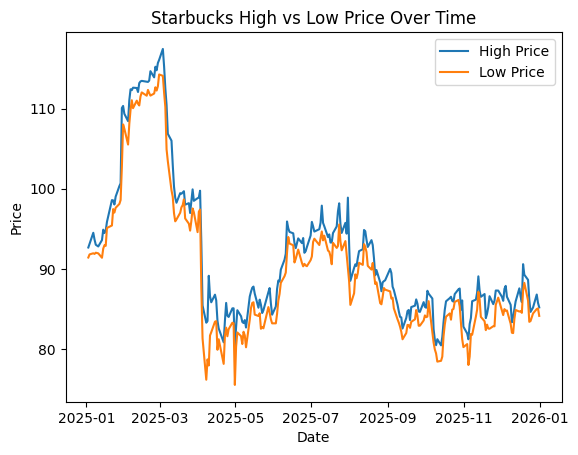

In [2]:
# Your Solution

df_sbux = pd.read_csv('SBUX.csv')
df_sbux['date'] = pd.to_datetime(df_sbux['date'], unit = 's')
df_sbux = df_sbux.set_index('date')

y_val1 = df_sbux['high']
y_val2 = df_sbux['low']

plt.plot(df_sbux.index, y_val1, label = 'High Price')
plt.plot(df_sbux.index, y_val2, label = 'Low Price')
plt.title('Starbucks High vs Low Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


Review Problem 2

**Concept:** *`DataFrame`: initialization, descriptive statistics, histogram.*

**Task:**

Using the `SBUX.csv` dataset:

1. Load the dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Compute the **daily return** of the stock using the `close` column (percentage change).
4. Display the **descriptive statistics** of the daily returns.
5. Create a **histogram** of the daily returns using 25 bins.
6. Identify **outliers** where the return falls outside of **mean ± 3 standard deviations**.
7. Print:
    *  the upper and lower bounds
    * the number of values above and below these bounds
    * the list of outlier values (sorted by date)


             high         low        open       close        volume  \
count  250.000000  250.000000  250.000000  250.000000  2.500000e+02   
mean    91.942080   89.640320   90.768760   90.812120  1.011185e+07   
std      8.933330    8.879755    8.923277    8.943933  5.116858e+06   
min     80.279999   75.500000   76.370003   78.459999  3.462700e+06   
25%     85.502501   83.272497   84.270000   84.432501  7.281875e+06   
50%     88.520000   86.395000   87.660000   87.260002  9.030450e+06   
75%     95.315001   93.227501   94.189999   94.394999  1.111635e+07   
max    117.459999  114.269997  116.040001  115.809998  4.479470e+07   

         adjclose  daily_return  
count  250.000000    249.000000  
mean    89.552137     -0.013012  
std      8.370072      2.160067  
min     77.897240    -11.216177  
25%     83.732018     -1.133576  
50%     86.777679      0.010747  
75%     92.891571      1.132297  
max    113.427155     11.281212  


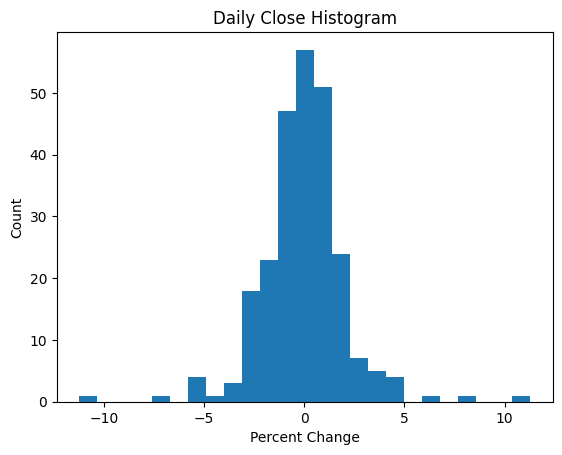

The Upper Bound is 6.467188888830805
The Lower Bound is -6.493212818695373
The count of outliers above the upper bound is 3
The count of outliers below the lower bound is 2
The list of outliers sorted by date:
                          close  daily_return
date                                         
2025-01-29 14:30:00  108.580002      8.136638
2025-04-03 13:30:00   88.260002    -11.216177
2025-04-04 13:30:00   82.099998     -6.979383
2025-04-09 13:30:00   88.680000     11.281212
2025-05-12 13:30:00   85.669998      6.687416


In [36]:
# Your Solution

df_sbux['daily_return'] = df_sbux['close'].pct_change() * 100
# df_sbux['daily_return']
print(df_sbux.describe())

plt.hist(df_sbux['daily_return'], bins = 25)
plt.title('Daily Close Histogram')
plt.xlabel('Percent Change')
plt.ylabel('Count')
plt.show()

dc_std = df_sbux['daily_return'].std()
dc_mean = df_sbux['daily_return'].mean()

upper_bound = dc_mean + (3 * dc_std)
lower_bound = dc_mean - (3 * dc_std)

print(f'The Upper Bound is {upper_bound}\nThe Lower Bound is {lower_bound}')

outliers_above = df_sbux[df_sbux['daily_return'] > upper_bound]
outliers_below = df_sbux[df_sbux['daily_return'] < lower_bound]

print(f'The count of outliers above the upper bound is {len(outliers_above)}\n\
The count of outliers below the lower bound is {len(outliers_below)}')

outliers = pd.concat([outliers_above , outliers_below]).sort_values('date')
print(f'The list of outliers sorted by date:\n\
{outliers[['close', 'daily_return']]}')



Test case for problem 2

**Problem 3**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Load the dataset into a DataFrame named `df_weather`.
2. Convert the `datetime` column to a pandas datetime format and set it as the index.
3. Use the icon column as a categorical variable and group the data by `icon`.
4. Create a **pie chart** showing the count of each weather icon category.

Your chart should include:
* labels for each category
* a title



/var/folders/dd/xldj5_xn66g02_h9jmm53tnm0000gn/T/ipykernel_13639/971811768.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])


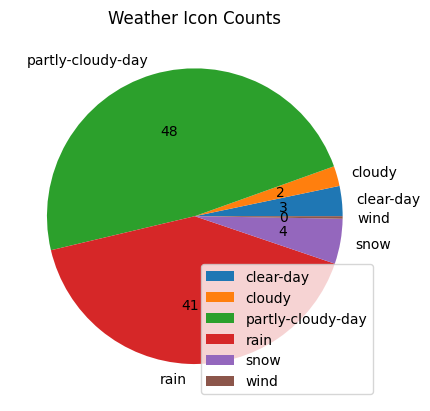

In [4]:
# Your Solution

df_weather = pd.read_csv('02215_weather.csv')
df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])
df_weather = df_weather.set_index('datetime')

df_weather_icon = df_weather.groupby('icon')
icon_counts = df_weather_icon.size()

plt.pie(icon_counts, labels = icon_counts.index, autopct = '%d')
plt.title('Weather Icon Counts')
plt.legend()
plt.show()




**Problem 4**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a **histogram** of the `tempmax` column for each weather condition group.

Your plot should include:
* 25 bins
* transparency so overlapping distributions can be seen
* a legend
* a title


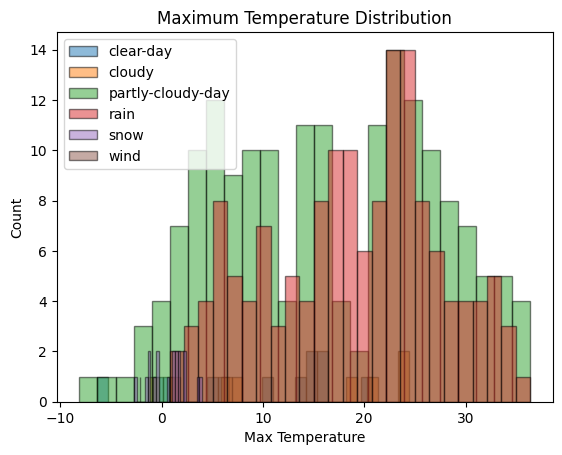

In [5]:
# Your Solution

plt.figure()

for icon, group_data in df_weather_icon:
    plt.hist(group_data['tempmax'], bins = 25, alpha = 0.5, edgecolor = 'black', label = icon)
    
plt.title(f'Maximum Temperature Distribution')
plt.xlabel('Max Temperature')
plt.ylabel('Count')
plt.legend()
plt.show()


**Problem 5**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a histogram of the `precip` column for each weather condition group.

Your plot should include:

* 10 bins
* transparency so overlapping distributions can be seen
* a legend
* a title



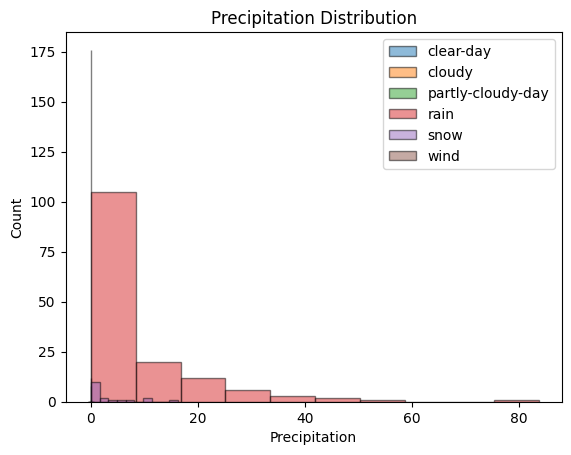

In [6]:
# Your Solution

plt.figure()

for icon, group_data in df_weather_icon:
    plt.hist(group_data['precip'], bins = 10, alpha = 0.5, edgecolor = 'black', label = icon)
    
plt.title(f'Precipitation Distribution')
plt.xlabel('Precipitation')
plt.ylabel('Count')
plt.legend()
plt.show()


**Problem 6**

**Concept:** *Grouping Data, plotting*


**Task:**


Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Compute the **mean** of the `tempmax` column for each weather condition group.
3. Create a **bar chart** to display the mean maximum temperature for each group.


Your plot should include:

* one bar for each weather icon category
* a title



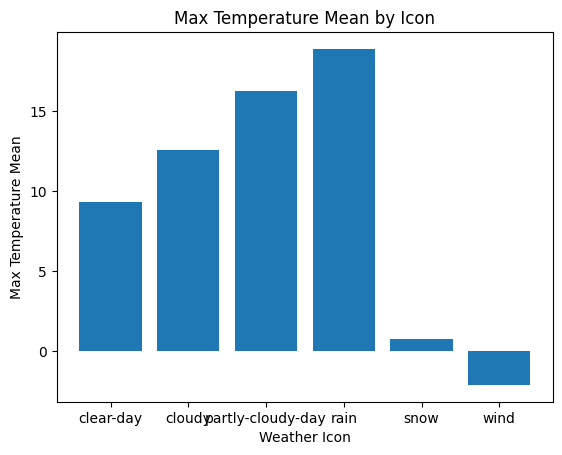

In [7]:
# Your Solution

tempmax_mean = df_weather_icon['tempmax'].mean()

temp_idx = tempmax_mean.index
temp_val = tempmax_mean.values

plt.bar(temp_idx, temp_val)
plt.xlabel('Weather Icon')
plt.ylabel('Max Temperature Mean')
plt.title('Max Temperature Mean by Icon')
plt.show()



**Problem 7**

**Concept:** *Grouping data, descriptive statistics*


**Task:**

Using the `02215_weather.csv` dataset:

1. Group the DataFrame by the `icon` column and store the result in a variable named `grouped_by_icon`.
2. Compute descriptive statistics for the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_statistics`.
3. Compute descriptive statistics for the `precip` column for each group and store the result in a variable named `grouped_precipitation_statistics`.
4. Compute the **mean** of the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_mean`.

Print all three results with clear labels:
* `"Tempmax grouped by conditions"`
* `"Precipitation grouped by conditions"`
* `"Mean of tempmax grouped by conditions"`


In [8]:
# Your Solution

grouped_by_icon = df_weather.groupby('icon')
grouped_tempmax_statistics = grouped_by_icon['tempmax'].describe()
grouped_precipitation_statistics = grouped_by_icon['precip'].describe()
grouped_tempmax_mean = grouped_by_icon['tempmax'].mean()

print(f'Tempmax grouped by conditions:\n\
{grouped_tempmax_statistics}\
Precipitation group by conditions:\n\
{grouped_precipitation_statistics}\n\
Mean of tempmax grouped by conditions:\n\
{grouped_tempmax_mean}')


Tempmax grouped by conditions:
                   count       mean        std  min    25%    50%     75%  \
icon                                                                        
clear-day           12.0   9.316667   8.230965 -6.4   4.15  12.10  15.225   
cloudy               8.0  12.575000  10.423565 -1.3   4.95  13.05  21.350   
partly-cloudy-day  176.0  16.246023  10.533554 -8.1   7.20  15.65  25.000   
rain               150.0  18.904000   8.498037  0.8  12.60  19.90  24.600   
snow                18.0   0.750000   1.805628 -2.7  -0.65   1.25   1.775   
wind                 1.0  -2.100000        NaN -2.1  -2.10  -2.10  -2.100   

                    max  
icon                     
clear-day          20.8  
cloudy             24.4  
partly-cloudy-day  36.4  
rain               36.4  
snow                4.0  
wind               -2.1  Precipitation group by conditions:
                   count      mean        std    min      25%     50%  \
icon                                 

QUERYING

The following data frame will be used in several questions.


In [9]:
# starter code
df_voter_data = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-11/newton_voters.csv", low_memory=False)
df_voter_data.index = df_voter_data["Voter ID Number"]
df_voter_data['Date of Birth'] = pd.to_datetime(df_voter_data['Date of Birth'])


**Problem 8**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Determine the **total number of voters** and print the result.
2. Compute the count of voters in each **Party Affiliation** category.
3. Create a **pie chart** showing the distribution of voters by party affiliation.

Your plot should include:
* labels for each category
* a title that includes the total number of voters


The total count of voters = 48793


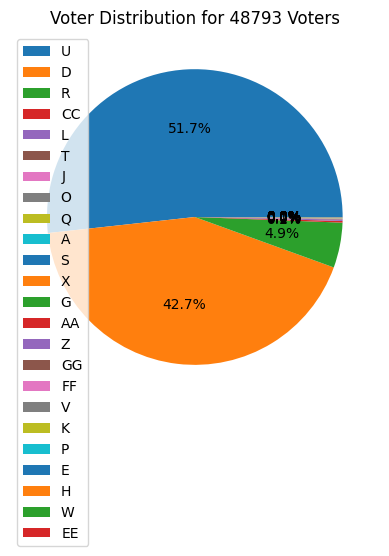

In [10]:
# Your Solution

voter_total = df_voter_data.query('voter_score != 0')
print(f'The total count of voters = {len(voter_total)}')

voter_party = voter_total['Party Affiliation'].value_counts()

plt.pie(voter_party, autopct= '%1.1f%%')
plt.title(f'Voter Distribution for {len(voter_total)} Voters')
plt.legend(voter_party.index)
plt.show()




**Problem 9**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_older_voters` that includes only voters born **before January 1, 1950**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these older voters.

Your plot should include:
* labels for each category
* a title that includes the number of older voters


The total voter count of older voters is 8236 voters


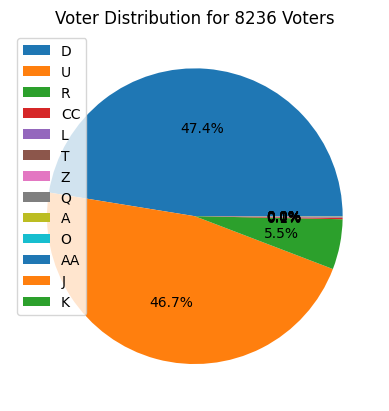

In [11]:
# Your Solution

# voter_total.head()
cutoff_old = pd.to_datetime("1950-01-01")
df_older_voters = voter_total.query('`Date of Birth` < @cutoff_old')
print(f'The total voter count of older voters is {len(df_older_voters)} voters')

older_voter_party = df_older_voters['Party Affiliation'].value_counts()

plt.pie(older_voter_party, autopct= '%1.1f%%')
plt.title(f'Voter Distribution for {len(df_older_voters)} Voters')
plt.legend(older_voter_party.index)
plt.show()



**Problem 10**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_younger_voters` that includes only voters born **after January 1, 2000**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these Younger voters.

Your plot should include:
* labels for each category
* a title that includes the number of younger voters


The total voter count of younger voters is 2946 voters


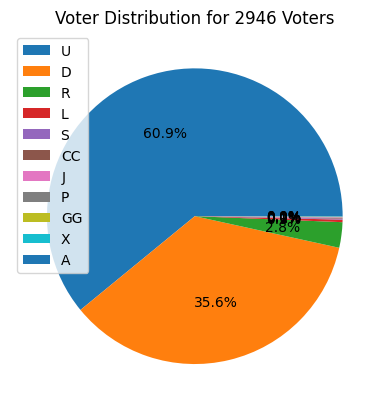

In [12]:
# Your Solution
# voter_total.head()
cutoff_young = pd.to_datetime("2000-01-01")
df_younger_voters = voter_total.query('`Date of Birth` > @cutoff_young')
print(f'The total voter count of younger voters is {len(df_younger_voters)} voters')

younger_voter_party = df_younger_voters['Party Affiliation'].value_counts()

plt.pie(younger_voter_party, autopct= '%1.1f%%')
plt.title(f'Voter Distribution for {len(df_younger_voters)} Voters')
plt.legend(younger_voter_party.index)
plt.show()



**Problem 11**

**Concept:** *Querying `DataFrame`s and graphing*



**Task:**

Using the `df_voter_data` DataFrame:
1. Identify all columns related to elections:
    * Select columns whose names contain the letter `"v"` but do **not** contain `"score"`
    * Store the result in a variable named `election_columns`

2. Compute the **voting participation percentage** for each election among all voters:
    * Store the result in a variable named `d1`
    * **Hint:** To calculate participation
        * Use `.sum()` on a column to count how many voters participated
        * Divide by the total number of voters using `len(df)`
        * Multiply by 100 to convert to a percentage

3. Create a filtered DataFrame named `df_high_voter_score`:
    * Include only voters with `voter_score >= 4`
    * Print the number of voters in this group

4. Compute the **voting participation percentage** for this group:
    * Store the result in a variable named `d2`

5. Create a filtered DataFrame named `df_unenrolled`:
    * Include only voters with `"Party Affiliation" == "U "`
    * Print the number of voters in this group

6. Compute the voting participation percentage for this group:
    * Store the result in a variable named `d3`

7. Combine the results into a new DataFrame named `d`:
    * Index should be the election columns
    * Columns should be:
        * `"all voters"`
        * `"high-propensity voters"`
        * `"unenrolled voters"`

8. Create a **bar chart** from this combined DataFrame.

Your plot should include:
* a title
* a key

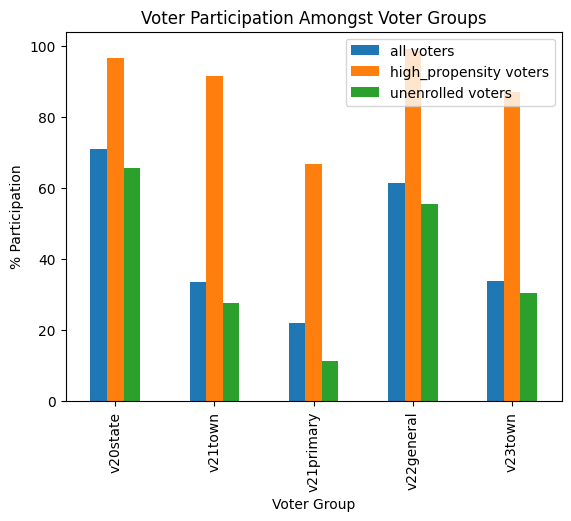

In [34]:
# Your Solution
df_voter_data.columns


election_columns = ['v20state', 'v21town', 'v21primary', 'v22general', 'v23town']
d1 = (df_voter_data[election_columns].sum() / len(df_voter_data[election_columns])) * 100

df_high_voter_score = df_voter_data.query('voter_score >= 4')
d2 = (df_high_voter_score[election_columns].sum() / len(df_high_voter_score[election_columns])) * 100

df_unenrolled = df_voter_data.query('`Party Affiliation` == "U "')
d3 = (df_unenrolled[election_columns].sum() / len(df_unenrolled[election_columns])) * 100

d = pd.DataFrame({'all voters' : d1,
                  'high_propensity voters' : d2,
                  'unenrolled voters' : d3})

d.plot(kind = 'bar')
plt.title('Voter Participation Amongst Voter Groups')
plt.ylabel('% Participation')
plt.xlabel('Voter Group')
plt.show()




**Problem 12**

**Concept:** *Joining `DataFrame`s*


**Task:**

You are given two DataFrames:
* `submissions`, which contains student IDs and their homework submission IDs
* `grades`, which contains homework grades indexed by submission ID

Using these DataFrames:
1. Inspect both DataFrames by printing them.
2. Join the `submissions` DataFrame with the `grades` DataFrame:
    * Match the `hw1_submission` column in `submissions` with the index of `grades`
    * Store the result in a variable named `result`
3. Update the index of the resulting DataFrame:
    * Set the index to the `student_id` column
4. Create a new DataFrame named `result_df`:
    * Remove the `student_id` column
5. Print the final DataFrame


Starter code:

In [14]:
# STARTER CODE:
submissions = pd.DataFrame(data={"student_id": ["U100", "U101", "U102", "U103", "U104"],
                        "hw1_submission": ["c1325", "b231", "a512", "e9999", "d8234"]})

grades = pd.DataFrame(index=["a512", "b231", "c1325", "d8234", "e9999"],
                        data={"hw1_grade": [0.99, 0.50, 0.62, 0.78, 1.00]} )


In [21]:
# Your Solution
print(submissions)
print(grades)

result = pd.merge(submissions, grades, left_on = 'hw1_submission', right_index= True)
result = result.set_index('student_id')
result_df = result
print(result_df)



  student_id hw1_submission
0       U100          c1325
1       U101           b231
2       U102           a512
3       U103          e9999
4       U104          d8234
       hw1_grade
a512        0.99
b231        0.50
c1325       0.62
d8234       0.78
e9999       1.00
           hw1_submission  hw1_grade
student_id                          
U100                c1325       0.62
U101                 b231       0.50
U102                 a512       0.99
U103                e9999       1.00
U104                d8234       0.78


**Problem 13**

**Concept:** *Joining `DataFrame`s*



**Task:**

You are given two datasets:
* `design_materials.tsv`, which contains materials and the quantity required per bed
* `material_costs.tsv`, which contains the cost per unit for each material

Using these datasets:
1. Load both datasets from the provided `.tsv` files using the correct separator.
2. Merge the two DataFrames:
    * Join on the `material` column
    * Store the result in a variable named `df_costs`
3. Create a new column named `cost`:
    * Compute it as:

      **quantity_per_bed × unit_cost**
4. Print the resulting DataFrame

In [28]:
# Your Solution

design_materials_df = pd.read_csv('design_materials.tsv', sep= '\t')
material_costs_df = pd.read_csv('material_costs.tsv', sep = '\t')

df_costs = pd.merge(design_materials_df, material_costs_df, on = 'material')
df_costs['cost'] = df_costs['quantity_per_bed'] * df_costs['unit_cost']

print(df_costs)



          design                    material  quantity_per_bed  unit_cost  \
0  4' x 4' x 18"                2" x 6" x 4'                20       5.92   
1  4' x 4' x 18"  8" x 8" x 16" Cinder Block                12       3.53   
2  4' x 8' x 18"                2" x 6" x 4'                 6       5.92   
3  4' x 8' x 18"                2" x 6" x 8'                14       7.62   
4  4' x 8' x 18"  8" x 8" x 16" Cinder Block                24       3.53   
5  4' x 4' x 12"                2" x 6" x 4'                16       5.92   
6  4' x 4' x 12"  8" x 8" x 16" Cinder Block                12       3.53   
7  4' x 8' x 12"                2" x 6" x 4'                 2       5.92   
8  4' x 8' x 12"                2" x 6" x 8'                12       7.62   
9  4' x 8' x 12"  8" x 8" x 16" Cinder Block                24       3.53   

     cost  
0  118.40  
1   42.36  
2   35.52  
3  106.68  
4   84.72  
5   94.72  
6   42.36  
7   11.84  
8   91.44  
9   84.72  


**Problem 14**

**Concept:** *joining `DataFrame`s*


**Task:**

You are given three stock datasets:
* BAC
* GM
* SBUX

Using these datasets:
1. Load each dataset into separate DataFrames:
    * `df_bac`, `df_gm`, and `df_sbux`
2. Convert the `date` column in each DataFrame to pandas datetime format and set it as the index.
3. Create a new DataFrame named `df_stock_prices`:
    * Use the index from `df_bac`
    * Add the following columns:
        * `"bac"` from `df_bac["close"]`
        * `"gm"` from `df_gm["close"]`
        * `"sbux"` from `df_sbux["close"]`
4. Create a **line plot** showing the stock prices over time.

Your plot should include:
* all three stocks on the same chart
* a title

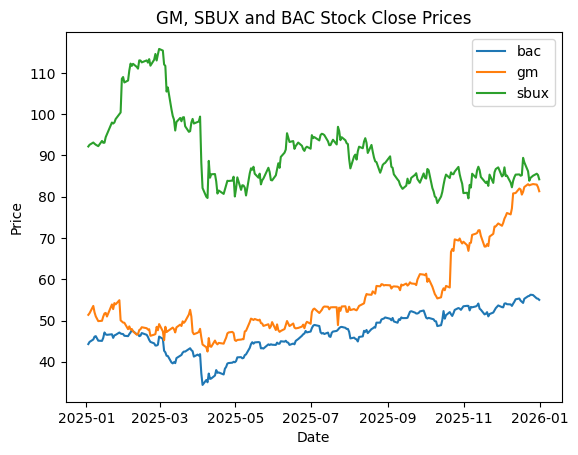

In [45]:
# Your Solution
df_bac = pd.read_csv('BAC.csv')
df_gm = pd.read_csv('GM.csv')

df_bac['date'] = pd.to_datetime(df_bac['date'], unit = 's')
df_bac = df_bac.set_index('date')
df_gm['date'] = pd.to_datetime(df_gm['date'], unit = 's')
df_gm = df_gm.set_index('date')

df_stock_prices = pd.DataFrame(index = df_bac.index)
df_stock_prices['bac'] = df_bac['close']
df_stock_prices['gm'] = df_gm['close']
df_stock_prices['sbux'] = df_sbux['close']

plt.plot(df_stock_prices, label = df_stock_prices.columns)
plt.legend()
plt.title('GM, SBUX and BAC Stock Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()






**Problem 15**

**Concept:** *joining `DataFrame`s*


**Task:**

Using the `df_stock_prices` DataFrame from **Problem 14**:
1. Compute the **relative prices** of each stock:
    * Divide all values by the first row of the DataFrame
    * Store the result in a variable named `df_stock_prices_relative`
2. Create a **line plot** of the relative prices.

Your plot should include:
* all three stocks on the same chart
* a title

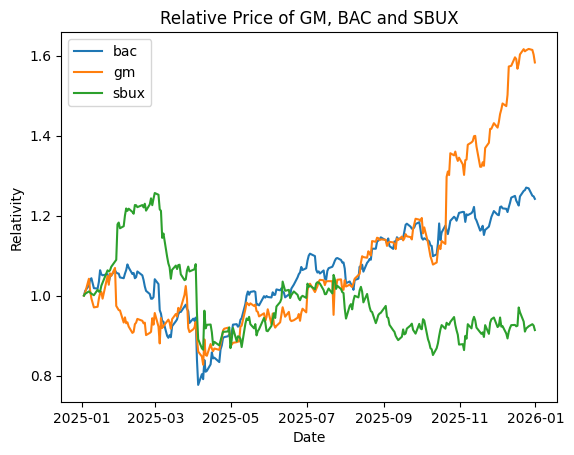

In [50]:
# Your Solution

df_stock_prices
df_stock_prices_relative = pd.DataFrame()

for col in ['bac', 'gm', 'sbux']:
    df_stock_prices_relative[col] = df_stock_prices[col] / df_stock_prices[col].iloc[0]

plt.plot(df_stock_prices_relative, label = df_stock_prices_relative.columns)
plt.legend()
plt.title('Relative Price of GM, BAC and SBUX')
plt.xlabel('Date')
plt.ylabel('Relativity')
plt.show()
